**Мы подошли к тому моменту, ради которого, по сути, и строилась вся система.**

До этого:

- мы разобрали токены и эмбеддинги,
- научились добавлять позицию,
- собрали Transformer block,
- получили logits,
- запустили training loop,
- увидели, как падает loss.

Сейчас мы с вами впервые дойдем до того, что модель будет генерировать текст. При этом важно помнить, что она не генерирует весь текст целиком, а только следующий токен, но если повторить это много раз, то выйдет как раз то, что нужно!

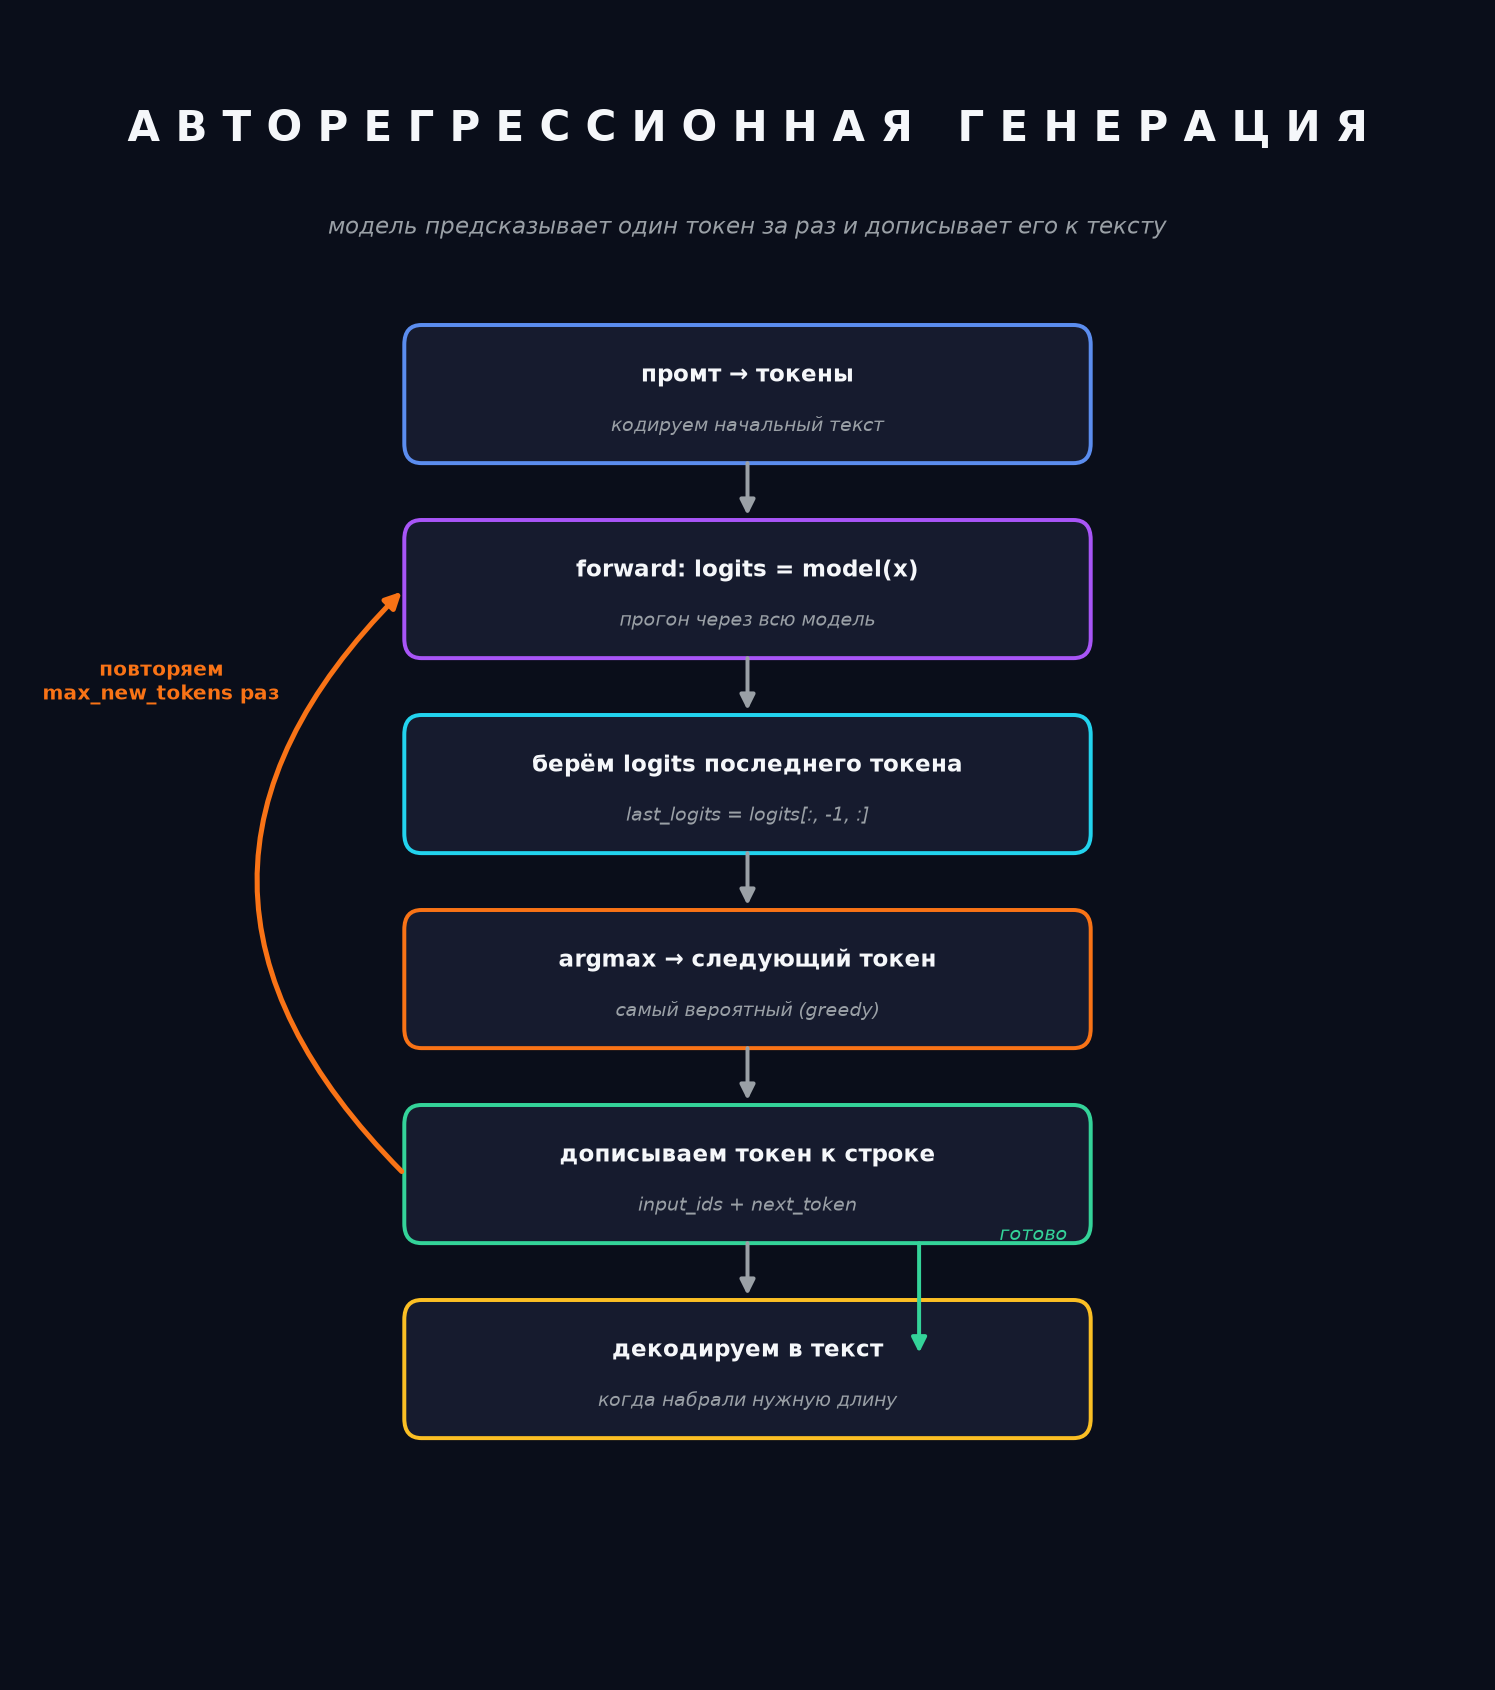

Мы с вами научились обучать модель, но результат обучения не сохранили. Давайте поправим `train.py` для этого.

По сути, просто сохраним результат с наименьшим loss.

Логика простая: как только средний **loss** за эпоху оказывается меньше прежнего минимума, мы перезаписываем `best_model.pth`. А в конце дополнительно сохраняем модель после последней эпохи и её конфигурацию.

Далее увеличим датасет, чтобы модель могла уловить связность в ответах.

Обновим `cat_story.txt`:

Once upon a time there was a cat. His name was Barsik. Barsik liked to sleep. Barsik loved to eat.
He was drinking milk. He was playing with a ball. The cat was fluffy. The cat was kind.
He lived in the house. The house was big. The cat was walking in the garden. There were flowers in the garden.
The cat was catching mice. The mice were afraid of the cat. The cat was sleeping on the couch. The sofa was soft.
The cat was purring loudly. The mistress loved the cat. The cat loved his mistress. They lived together.
The cat woke up in the morning. He was hungry. The hostess was giving food. The cat ate deliciously.
Then the cat washed up. He rubbed his face with his paw. The cat was clean. The cat was beautiful.
In the evening, the cat got tired. He was going to bed. I slept soundly. The cat was dreaming.
In the dream, the cat was flying. He was catching a big mouse. The mouse was running fast. The cat didn't catch up.
The sun was shining in the morning. The cat was basking in the window. The window was warm. The cat was pleased.

**Чем больше связных предложений в тексте, тем больше устойчивых переходов между токенами модель сможет запомнить - а значит, генерация станет осмысленнее.**

В корне проекта появятся сохранённая лучшая модель, модель после последней эпохи и конфигурация. Это полезно, когда надо понять, где и что подкрутить.

- `best_model.pth` - лучшая модель. Состояние модели с минимальной потерей во время обучения. Будем использовать для генерации.

- `final_model.pth` - финальная модель. Состояние модели после последней эпохи обучения. Нужна для анализа и сравнения.

- `model_config.json` - конфигурация модели. JSON-файл с параметрами модели и обучения.

Создадим теперь файл `generate.py`

Главная функция **generate** - это и есть авторегрессионная генерация:

- кодируем промт в токены;

- в цикле обрезаем вход до max_length, прогоняем через модель и берём логиты последнего токена;

- argmax выбирает самый вероятный следующий токен (greedy-декодинг);

- добавляем токен к последовательности и повторяем;

- в конце декодируем всё обратно в текст.

- Веса берём из best_model.pth - лучшей модели, сохранённой на прошлом шаге.

И теперь можно полноценно попробовать сгенерировать свой текст!

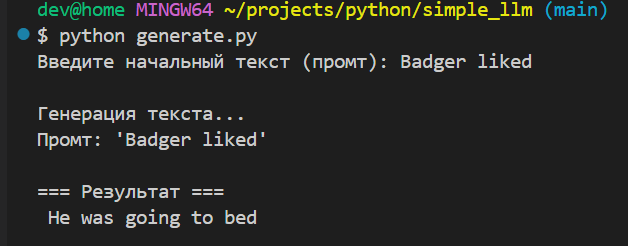

Конечно, если вы спросите, например, как зовут кота, модель не ответит. Почему? Потому что, чтобы модель отвечала по тексту, нужно обучать её на парах «Вопрос - Ответ».

Что-то типа того:

`Текст: Иван вышел из дома. Он был грустный.
Вопрос: Кто вышел из дома?
Ответ: Иван.`

`Текст: Пошёл дождь. Иван открыл зонт.
Вопрос: Что открыл Иван?
Ответ: Зонт.`

Попробуем использовать готовый датасет с пьесой Шекспира - так мы сможем уловить паттерны всей пьесы. Файл называется `input.txt` - его нужно и указать в `config.py`

Запускаем обучение - в этот раз это уже очень долгая процедура!

Запускаем генерацию, вводим промт Old John of Gaunt is.

И получаем ответ:

Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Введите начальный текст (промт): Old John of Gaunt is

Генерация текста...
Промт: 'Old John of Gaunt is'

=== Результат ===

Old John of Gaunt is frank'd,

And yet thou hast made me, and my tent;

And so much up

И что мы видим! Модель выучила стиль Шекспира. Она не просто копирует слова - она выучила паттерны стиля!

Разберём ответ:

Old John of Gaunt is [предикат],

And yet thou hast [глагол] me, and my [существительное];

And so much [направление]

Модель понимает:

- после **is** нужно прилагательное/причастие;
- после **thou hast** нужен глагол;
- структура предложения соблюдена.

Модель продолжила логично: Old John of Gaunt - это имя персонажа из шекспировских хроник, и модель это «помнит» через паттерны обучения.

**В целом на этом всё - курс по созданию LLM логически завершён.** Но сейчас у нас есть одна проблема: модель не отвечает на вопросы, она может только угадать следующий токен. Далее, мы научим отвечать модель как chatGPT!